#### Import the required packages

In [ ]:
import pandas as pd
import numpy as np
import re
# Train-test split
from  sklearn.model_selection import train_test_split
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
#models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
#evaluation of the model
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
#visualization 
import matplotlib.pyplot as plt
# nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /home/obanda/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/obanda/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/obanda/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/obanda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Load the dataset

In [12]:
# Load the cleaned dataset and clinical stop words
df = pd.read_csv("../data/top_mtsamples.csv")

In [ ]:
# Load custom clinical stop words
with open("../data/clinical-stopwords.txt") as f:
    clinical_stopwords={
        line.strip().lower()
        for line in f
        if line.strip() and not line.startswith("#")
    }
# Load NLTK English stop words
english_stopwords = set(stopwords.words("english"))
# Combine English and clinical stop words
all_stopwords = english_stopwords.union(clinical_stopwords)

#### Prepreocessing

In [ ]:
#create a prepreocessing function
def preprocess_text(text):
    """
    Clean and preprocess clinical text for TF-IDF.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Remove numbers and punctuation (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Split text into individual words
    tokens = word_tokenize(text)

    # Remove stop words and lemmatize the remaining words
    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in clinical_stopwords
    ]

    # Join the cleaned words back into a sentence
    return " ".join(cleaned_tokens)

In [26]:
# Apply preprocessing to all transcriptions
df["cleaned_text"] = df["transcription"].apply(preprocess_text)

#### Define the features and labels

In [30]:
# Input features
X = df["cleaned_text"]
# Target labels
y = df["medical_specialty_clean"]

#### Split the data into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
#print(y_train.value_counts(normalize=True))


#### Create the TF-IDF Vectorizer

In [38]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
#Learn the vocabulary from the training data | Computes IDF weights
X_train_tfidf = tfidf.fit_transform(X_train)
#transform the test data | use just transform so that the vectorizer does not learn anything from the test data
X_test_tfidf = tfidf.transform(X_test)


#### Training the Linear SVC model

In [39]:
# Create the Linear SVC model
svc_model = LinearSVC(random_state=42)
# Train the model
svc_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

#### Make Predictions
- Use the trained model to predict the medical specialties of the test set

In [ ]:
# Predict the medical specialties of the test set
y_pred_svc = svc_model.predict(X_test_tfidf)
# View the first 10 predictions
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svc
})
comparison.head(10)

,Actual,Predicted
0,Orthopedic,Radiology
1,Neurology,General Medicine
2,Surgery,Obstetrics / Gynecology
3,Surgery,Gastroenterology
4,Surgery,Orthopedic
5,Surgery,Obstetrics / Gynecology
6,General Medicine,General Medicine
7,Surgery,Orthopedic
8,Surgery,Surgery
9,Surgery,Orthopedic


#### Evaluate the Model

In [44]:
accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred_svc))

Accuracy: 0.3852
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.37      0.42      0.40       113
          Gastroenterology       0.26      0.20      0.22        71
          General Medicine       0.78      0.80      0.79        82
                 Neurology       0.41      0.56      0.47        55
   Obstetrics / Gynecology       0.24      0.31      0.27        39
                Orthopedic       0.24      0.26      0.25        96
                 Radiology       0.25      0.16      0.20        85
                   Surgery       0.40      0.40      0.40       346
                   Urology       0.32      0.24      0.28        45

                  accuracy                           0.39       932
                 macro avg       0.36      0.37      0.36       932
              weighted avg       0.38      0.39      0.38       932



#### Confusion Matrix

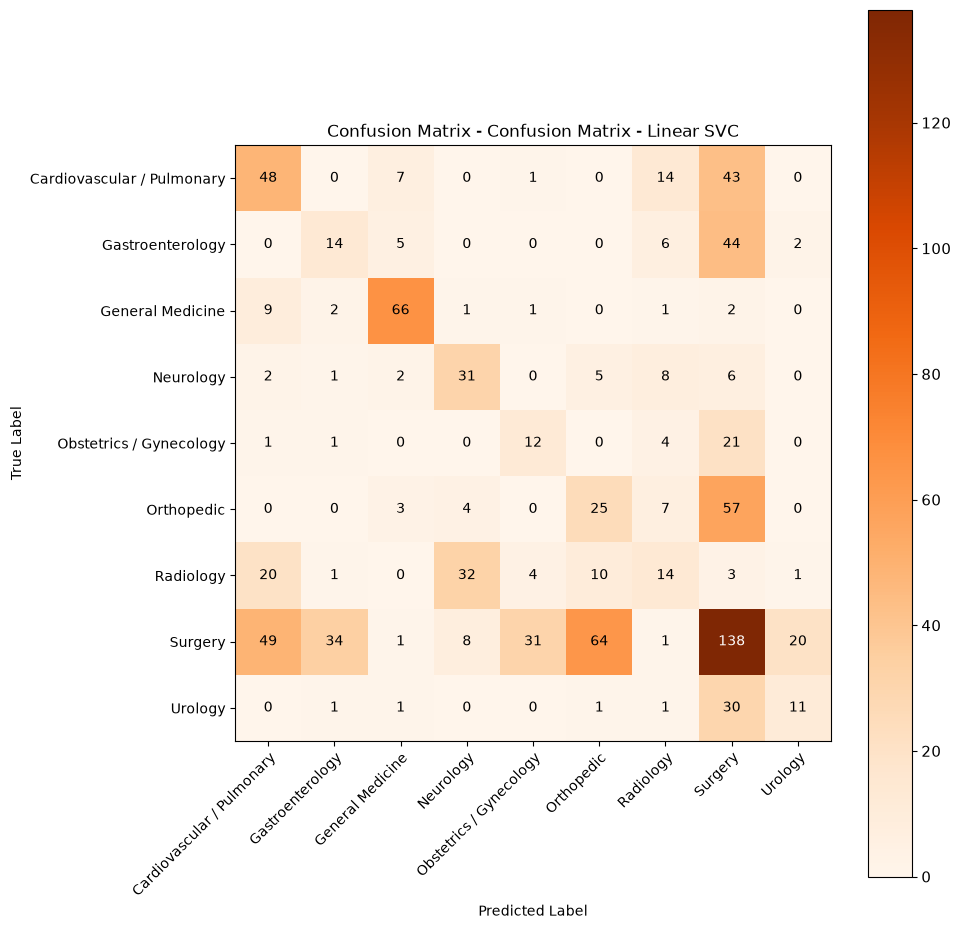

In [61]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svc)
fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(cm, interpolation='nearest', cmap="Oranges")
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=11)
classes = svc_model.classes_
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    yticklabels=classes,
    xlabel='Predicted Label',
    ylabel='True Label',
    title='Confusion Matrix - Confusion Matrix - Linear SVC'
)
plt.setp(ax.get_xticklabels(),
         rotation=45,
         ha="right",
         rotation_mode="anchor")
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            fontsize=10,
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

### Report from the confusion matrix for Linear SVC

The confusion matrix shows that the Linear SVC model performs well for General Medicine and Neurology but struggles to distinguish clinically related specialties. The greatest confusion occurs between Surgery and Orthopedic, Gastroenterology, and Obstetrics/Gynecology, indicating substantial overlap in the terminology used within operative reports. Similarly, Radiology reports are frequently misclassified as Neurology due to shared neurological imaging vocabulary. These findings suggest that additional feature engineering or model tuning may improve discrimination between related medical specialties.
To improve the mode:
- Tune the Linear SVC model by:
    - Increase or decrease the regularization parameter (C).
    - Try class_weight="balanced" to reduce the effect of class imbalance
- Experiment with TF-IDF
    - Compare ngram_range=(1,2) and (1,3)
    - Try increasing max_features (e.g., 15,000 or 20,000).
    - Adjust min_df if necessary
- **Train another classifier**
    - Logistic Regression

#### Create the multinormial Logistic Regression Model

In [47]:
# Create the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

#### Train the Model

In [48]:
# Train the model
lr_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Make Predictions

In [49]:
# Predict the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

#### Evaluate Accuracy and Classification Report

In [51]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.4742
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.45      0.46      0.46       113
          Gastroenterology       0.35      0.17      0.23        71
          General Medicine       0.69      0.83      0.76        82
                 Neurology       0.51      0.62      0.56        55
   Obstetrics / Gynecology       0.27      0.21      0.23        39
                Orthopedic       0.29      0.23      0.25        96
                 Radiology       0.29      0.16      0.21        85
                   Surgery       0.50      0.64      0.56       346
                   Urology       0.50      0.22      0.31        45

                  accuracy                           0.47       932
                 macro avg       0.43      0.39      0.40       932
              weighted avg       0.45      0.47      0.45       932



#### Confusion Matrix

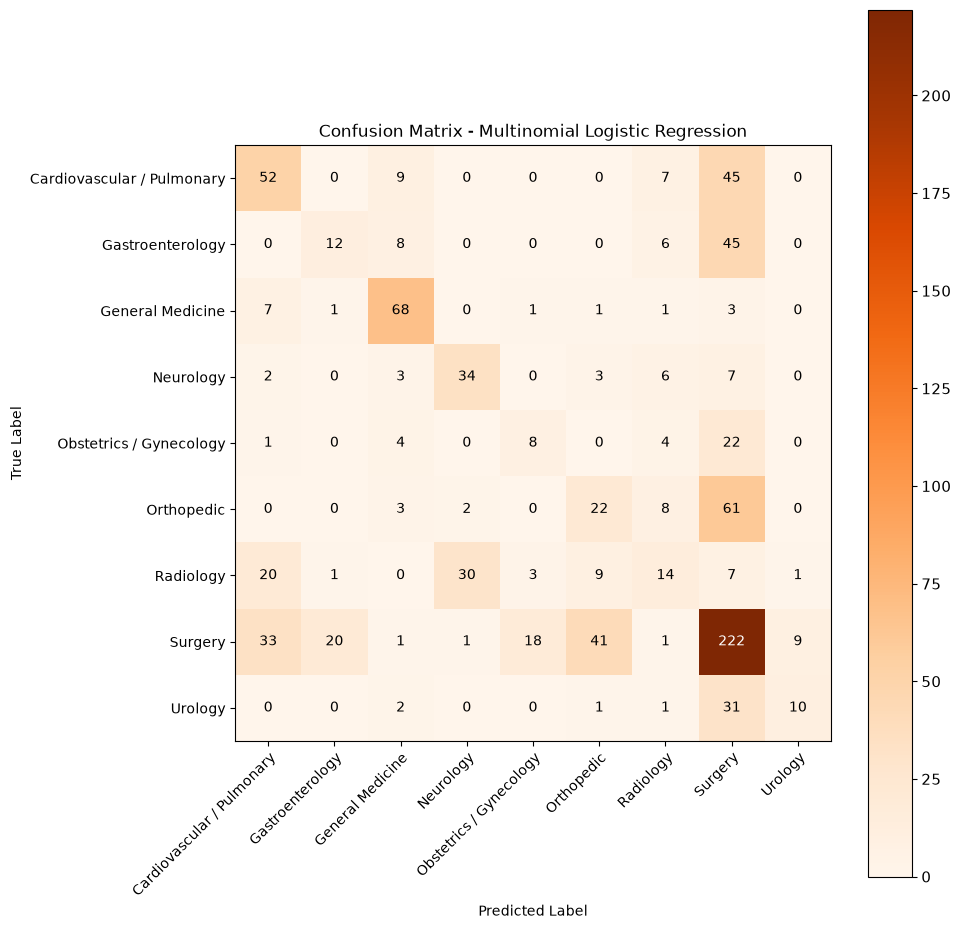

In [59]:


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(cm, interpolation='nearest', cmap="Oranges")
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=11)
classes = lr_model.classes_
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    yticklabels=classes,
    xlabel='Predicted Label',
    ylabel='True Label',
    title='Confusion Matrix - Multinomial Logistic Regression'
)
plt.setp(ax.get_xticklabels(),
         rotation=45,
         ha="right",
         rotation_mode="anchor")
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            fontsize=10,
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

### Report from the confusion matrix for Logistic Regression

Two machine learning classifiers, Linear Support Vector Classifier (Linear SVC) and Multinomial Logistic Regression, were evaluated using TF-IDF features extracted from clinical transcriptions. Logistic Regression achieved a higher overall accuracy (47.4%) than Linear SVC (38.5%) and also produced higher macro-averaged precision, recall, and F1-score. The confusion matrices showed that both models frequently confused clinically related specialties, particularly Surgery, Orthopedic, Gastroenterology, and Obstetrics/Gynecology, reflecting the overlap in medical terminology across these specialties. Despite these challenges, Logistic Regression demonstrated superior overall performance and was selected as the better-performing classifier for this dataset